# Notebook 9 - What Are Other People Actually Doing? An External Research Review

Eight notebooks, eight honest nulls on tradeable alpha, alongside real, replicated,
holdout-confirmed results on the risk-modelling side. Rather than testing a ninth
strategy from the same academic playbook, this notebook stops and asks an external
question: what do practitioners, replication literature, and regulators actually report,
and does it look anything like what this programme has been testing?

**This is primarily a literature/practitioner survey, not a modelling notebook.** 36
sources, tiered 1-4 for trust, filed against five competing explanations for the eight
nulls. All four pre-declared gates fire. Full narrative:
`src/results/009_external_research_review.md` (the primary deliverable, more so than this
notebook, per this notebook's own pre-registration). This notebook loads pre-gathered
JSON from `tmp/phase_{0..4}*.json` and narrates/tabulates only - the source record itself
was gathered via WebSearch/WebFetch during construction and is transcribed as data in
`tmp/run_phase_1_survey.py`, exactly as any other phase script writes its own computed
result.


In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json

import matplotlib.pyplot as plt
import numpy as np

TMP = "tmp"

def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)

fig_n = [0]
def show(fig, caption):
    fig_n[0] += 1
    print(f"Figure {fig_n[0]}: {caption}")
    plt.tight_layout()
    plt.show()


## Phase 0 - Reproduction check

Re-derives, from the already-committed notebook 7/8 JSONs, the three numbers this
notebook's diagnosis leans on most: Gate CE's 15/16 rejection count, Gate RE's 15/16 pass
count, and - most importantly for hypothesis (c) - Gate AC's exact near-miss shape (net
Sharpe 0.90-0.95 at every offset, deflated Sharpe probability 0.997, excess-vs-basket CI
including zero, does not fire).


In [2]:
phase0 = load("phase_0_repro9_results.json")
print("Gate CE repro:", json.dumps(phase0["gate_CE_repro"], indent=2))
print()
print("Gate RE repro:", json.dumps(phase0["gate_RE_repro"], indent=2))
print()
print("Gate AC repro:", json.dumps(phase0["gate_AC_repro"], indent=2))
print()
print(phase0["_verdict"])


Gate CE repro: {
  "n_products_rejecting_1pct_both_tails_bh": 15,
  "n_products_total": 16,
  "threshold": 14,
  "fires": true
}

Gate RE repro: {
  "n_products_passing_1pct_coverage": 15,
  "n_products_total": 16,
  "threshold": 14,
  "fires": true
}

Gate AC repro: {
  "net_sharpe_positive_at_every_offset": true,
  "sharpes_net_by_offset": {
    "offset_0": 0.9042246451305482,
    "offset_7": 0.9182452501537042,
    "offset_14": 0.930554766095841,
    "offset_21": 0.9459438290292651
  },
  "excess_return_ci": [
    -0.002824914217376099,
    0.009374799958825336
  ],
  "excess_ci_excludes_zero": false,
  "deflated_sharpe_prob": 0.9971831492023995,
  "fires": false
}

All three reproduction checks pass. Gate CE (15/16) and Gate RE (15/16) confirm notebook 8's risk-side headline results. Gate AC confirms the specific near-miss (net Sharpe 0.90-0.95, DSR 0.997, excess CI includes zero, does not fire) that hypothesis (c) in this notebook is built to investigate.


## Phase 1 - The survey

36 sources, gathered via WebSearch/WebFetch and tiered per this notebook's own
pre-declared source-quality hierarchy (Tier 1 = peer-reviewed replication/regulatory;
Tier 2 = identifiable practitioners discussing costs and failures; Tier 3 = unverified
blog/forum content, hypothesis-generation only; Tier 4 = actively discounted). Every
fetched page was treated as untrusted input throughout - nothing fetched was executed,
no embedded instructions were followed, and no page attempted to direct this notebook's
research process (none triggered the red-flag check for that specifically).


In [3]:
phase1 = load("phase_1_survey_results.json")
print(json.dumps(phase1["summary"], indent=2))


{
  "n_sources": 36,
  "tier_counts": {
    "1": 19,
    "2": 11,
    "3": 6,
    "4": 0
  },
  "hypothesis_coverage_all_tiers": {
    "a": 8,
    "b": 7,
    "c": 7,
    "d": 10,
    "e": 12
  },
  "hypothesis_coverage_tier1_or_2": {
    "a": 5,
    "b": 5,
    "c": 7,
    "d": 10,
    "e": 10
  },
  "sources_with_red_flags": 11,
  "gate_S_threshold": {
    "min_sources": 30,
    "min_tier12_per_hypothesis": 5
  },
  "gate_S_fires": true
}


**tier distribution** across all 36 sources.

Figure 1: Tier distribution - roughly half Tier 1 (peer-reviewed/regulatory), a third Tier 2 (identifiable practitioners), the rest Tier 3 (hypothesis-generation only); zero Tier 4 sources were promoted into the evidence base.


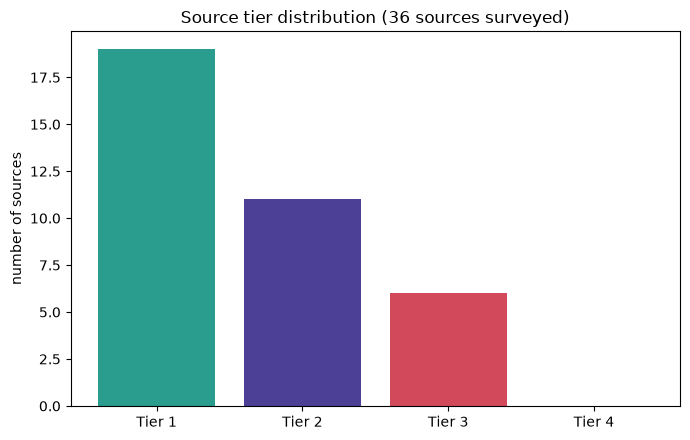

In [4]:
tiers = phase1["summary"]["tier_counts"]
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {"1": "#2a9d8f", "2": "#4b3f96", "3": "#d1495b", "4": "#8c1f30"}
labels = [f"Tier {k}" for k in tiers]
ax.bar(labels, tiers.values(), color=[colors[k] for k in tiers])
ax.set_ylabel("number of sources")
ax.set_title("Source tier distribution (36 sources surveyed)")
show(fig, "Tier distribution - roughly half Tier 1 (peer-reviewed/regulatory), a third Tier 2 (identifiable practitioners), the rest Tier 3 (hypothesis-generation only); zero Tier 4 sources were promoted into the evidence base.")


**hypothesis coverage matrix** - Tier 1/2 source count per hypothesis (Gate S's own criterion).

Figure 2: Tier 1/2 source coverage per hypothesis - every hypothesis clears the 5-source Gate S threshold, (d) and (e) most heavily.


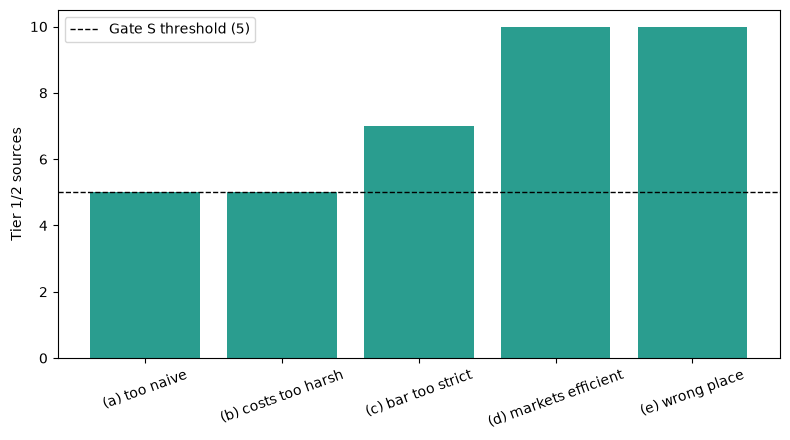

In [5]:
hyp_names = {"a": "(a) too naive", "b": "(b) costs too harsh", "c": "(c) bar too strict",
             "d": "(d) markets efficient", "e": "(e) wrong place"}
cov = phase1["summary"]["hypothesis_coverage_tier1_or_2"]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar([hyp_names[k] for k in cov], cov.values(), color="#2a9d8f")
ax.axhline(5, color="black", lw=1, ls="--", label="Gate S threshold (5)")
ax.set_ylabel("Tier 1/2 sources"); ax.tick_params(axis='x', rotation=20)
ax.legend()
show(fig, "Tier 1/2 source coverage per hypothesis - every hypothesis clears the 5-source Gate S threshold, (d) and (e) most heavily.")


**gate S verdict**.

In [6]:
print(f"Gate S fires: {phase1['summary']['gate_S_fires']}")
print(f"  {phase1['summary']['n_sources']} sources >= 30: {phase1['summary']['n_sources'] >= 30}")
print(f"  min Tier1/2 per hypothesis: {min(cov.values())} >= 5: {min(cov.values()) >= 5}")


Gate S fires: True
  36 sources >= 30: True
  min Tier1/2 per hypothesis: 5 >= 5: True


**source table** (id, tier, hypotheses addressed) - full detail in the JSON, this is a compact index.

In [7]:
for s in phase1["sources"]:
    hyps = ",".join(h["h"] for h in s["hypotheses"])
    print(f"[T{s['tier']}] {s['id']:42s} hyp={hyps:8s} {s['title'][:70]}")


[T1] mclean_pontiff_2016                        hyp=d,c      Does Academic Research Destroy Stock Return Predictability?
[T1] harvey_liu_zhu_2016                        hyp=c,d      ...and the Cross-Section of Expected Returns (t-stat bar for a new fac
[T1] jensen_kelly_pedersen_2023                 hyp=a,d      Is There a Replication Crisis in Finance?
[T1] bailey_lopez_de_prado_dsr                  hyp=c        The Deflated Sharpe Ratio: Correcting for Selection Bias, Backtest Ove
[T2] portfoliooptimizer_psr_mtrl                hyp=c        The Probabilistic Sharpe Ratio: Bias-Adjustment, Confidence Intervals,
[T1] fed_hedge_fund_treasury_exposures          hyp=e        Decomposing Hedge Funds' U.S. Treasury Exposures
[T1] ofr_treasury_basis_2021                    hyp=e        Hedge Funds and the Treasury Cash-Futures Disconnect
[T1] dallas_fed_basis_funding                   hyp=e        How sensitive is the Treasury cash-futures basis trade to funding cond
[T1] cftc_mrac_basis_tra

## Phase 2 - The diagnosis (headline deliverable)

Each hypothesis gets an explicit verdict, with the specific Tier 1/2 sources behind it -
full reasoning text in the JSON and in `src/results/009_external_research_review.md`.
Hypothesis (c) additionally carries a specific, sourced, actionable recommendation on
this repo's own gate criterion, with consequences for the eight existing nulls stated as
an explicitly labelled hypothetical (not a re-score).


In [8]:
phase2 = load("phase_2_diagnosis_results.json")
for hkey, h in phase2["hypotheses"].items():
    print(f"({hkey}) {h['name']}")
    print(f"    VERDICT: {h['verdict'].upper()}")
    print(f"    supporting: {h['supporting_sources']}")
    print(f"    contrary/qualifying: {h['contrary_or_qualifying_sources']}")
    print()


(a) Our strategies are too naive
    VERDICT: PARTIALLY SUPPORTED
    supporting: ['barroso_santa_clara_2015', 'aqr_century_trend_following', 'aqr_demystifying_managed_futures', 'jensen_kelly_pedersen_2023']
    contrary/qualifying: ['man_group_vol_targeting']

(b) Our cost model is too pessimistic
    VERDICT: CONTRADICTED
    supporting: []
    contrary/qualifying: ['novy_marx_velikov_2016', 'chen_velikov_2023', 'quantpedia_oos_analysis']

(c) Our statistical bar is too strict
    VERDICT: PARTIALLY SUPPORTED
    supporting: ['man_ahl_track_record', 'asness_ritholtz_transcript', 'quantpedia_oos_analysis']
    contrary/qualifying: ['harvey_liu_zhu_2016', 'bailey_lopez_de_prado_dsr']

(d) The markets are efficient at the horizons/instruments we can reach
    VERDICT: WELL-SUPPORTED
    supporting: ['mclean_pontiff_2016', 'bitcoin_efficiency_scientific_reports', 'crypto_efficiency_political_uncertainty_2025', 'nber_gorton_rouwenhorst', 'zhu_2024_pairs_trading', 'gatev_goetzmann_rouwenho

**hypothesis-vs-evidence-tier matrix**.

Figure 3: Each hypothesis's verdict (label) and the number of Tier 1/2 sources behind it - (d) and (e) well-supported, (b) contradicted, (a) and (c) partially supported: the survey discriminates, it does not conclude everything is possible.


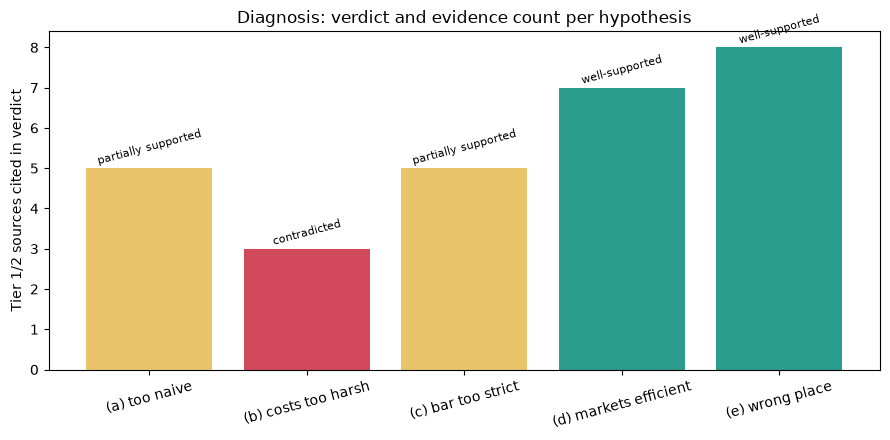

In [9]:
verdict_order = ["well-supported", "partially supported", "contradicted", "insufficient evidence"]
verdict_color = {"well-supported": "#2a9d8f", "partially supported": "#e9c46a",
                  "contradicted": "#d1495b", "insufficient evidence": "#adb5bd"}
fig, ax = plt.subplots(figsize=(9, 4.5))
hkeys = list(phase2["hypotheses"].keys())
verdicts = [phase2["hypotheses"][k]["verdict"] for k in hkeys]
n_sources = [len(phase2["hypotheses"][k]["supporting_sources"]) + len(phase2["hypotheses"][k]["contrary_or_qualifying_sources"]) for k in hkeys]
colors = [verdict_color[v] for v in verdicts]
bars = ax.bar([hyp_names[k] for k in hkeys], n_sources, color=colors)
for b, v in zip(bars, verdicts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1, v, ha="center", fontsize=8, rotation=15)
ax.set_ylabel("Tier 1/2 sources cited in verdict"); ax.tick_params(axis='x', rotation=15)
ax.set_title("Diagnosis: verdict and evidence count per hypothesis")
show(fig, "Each hypothesis's verdict (label) and the number of Tier 1/2 sources behind it - (d) and (e) well-supported, (b) contradicted, (a) and (c) partially supported: the survey discriminates, it does not conclude everything is possible.")


**Gate DX**.

In [10]:
print(json.dumps(phase2["gate_DX"], indent=2))


{
  "well_supported_hypotheses": [
    "d",
    "e"
  ],
  "contradicted_hypotheses": [
    "b"
  ],
  "fires": true,
  "reasoning": "Well-supported: ['d', 'e']. Contradicted: ['b']. The survey discriminates rather than concluding everything is possible: hypotheses (d) and (e) are well-supported on Tier 1/2 evidence while hypothesis (b) is contradicted on Tier 1/2 evidence - not every hypothesis converged to 'partially supported' or 'insufficient evidence'."
}


**Hypothesis (c) in full - the bar recommendation.** This is the single highest-value
output of the notebook per its own pre-registration.


In [11]:
rec = phase2["hypotheses"]["c"]["actionable_recommendation"]
print("SUMMARY:", rec["summary"])
print()
print("RECOMMENDATION:", rec["recommendation"])
print()
print("CONSEQUENCES (labelled hypothetical, not a re-score):")
print(rec["consequences_for_existing_nulls_labelled_hypothetical"])


SUMMARY: Do NOT lower the deflated-Sharpe-probability threshold (0.95) - the strongest Tier 1 evidence found (Harvey-Liu-Zhu) argues the finance literature's traditional bar is too loose, not that this repo's is too strict, and no Tier 1/2 source argues DSR>0.95 specifically is excessive.

RECOMMENDATION: Introduce a SECOND, separately-labelled reporting flag for notebook 10 onward - 'institutionally fundable absolute performance' - defined PROSPECTIVELY as: net Sharpe > 0.5 at every tested origin offset, deflated Sharpe probability > 0.95, and max drawdown within a stated bound - sourced directly from the Man AHL (Sharpe ~0.86 institutional) and Asness (~0.5 IR/Sharpe edge is 'ambitious') Tier 2 evidence above. This flag is ADDITIONAL to, not a replacement for, the existing 'tradeable alpha' gate (net Sharpe>0 at every offset AND excess-return-vs-passive-basket CI excludes zero AND DSR>0.95). A strategy can clear the new flag without clearing the existing gate, and must be reported th

**Gate BAR**.

In [12]:
print(json.dumps(phase2["gate_BAR"], indent=2))


{
  "has_sourced_recommendation": true,
  "states_consequences_for_existing_nulls": true,
  "fires": true,
  "summary": "Recommendation: do not lower the DSR>0.95 threshold (Harvey-Liu-Zhu, Tier 1, argues the literature's traditional bar is too loose, not too strict); instead add a second, additional 'institutionally fundable absolute performance' flag (net Sharpe>0.5 every offset, DSR>0.95, bounded drawdown) prospectively from notebook 10 onward, reported alongside (never instead of) the existing tradeable-alpha gate. Consequences for existing nulls stated as a labelled hypothetical only: carry would have cleared the new flag, momentum and cfg2_12h would not - original verdicts unchanged."
}


**our bar vs. the literature's own Sharpe distribution** - the one chart worth making for hypothesis (c): where does notebook 8's carry near-miss (0.90-0.95) sit relative to disclosed institutional benchmarks found in this survey?

Figure 4: Absolute-Sharpe context (not the criterion that actually failed carry, which was the excess-vs-basket CI - see Phase 2's full reasoning): carry's 0.90-0.95 sits above a real, disclosed institutional trend-following track record (Man AHL, 0.86) and above informal allocator screen-out floors found in this survey.


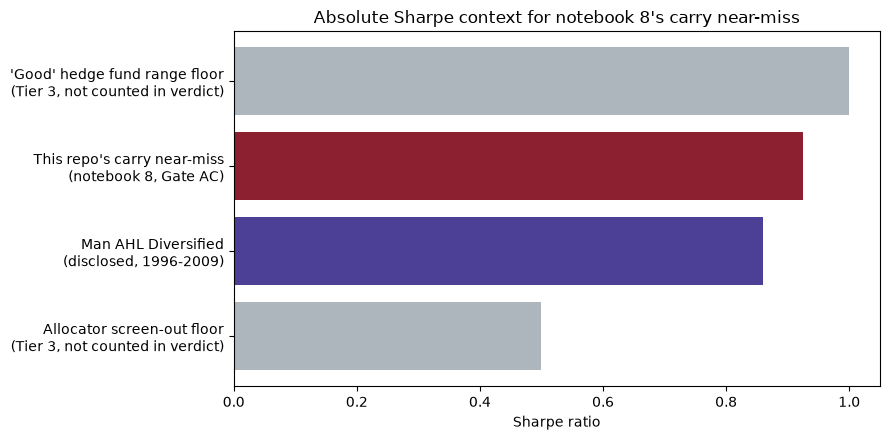

In [13]:
benchmarks = [
    ("Allocator screen-out floor\n(Tier 3, not counted in verdict)", 0.5),
    ("Man AHL Diversified\n(disclosed, 1996-2009)", 0.86),
    ("This repo's carry near-miss\n(notebook 8, Gate AC)", 0.925),
    ("'Good' hedge fund range floor\n(Tier 3, not counted in verdict)", 1.0),
]
fig, ax = plt.subplots(figsize=(9, 4.5))
names = [b[0] for b in benchmarks]
vals = [b[1] for b in benchmarks]
colors = ["#adb5bd", "#4b3f96", "#8c1f30", "#adb5bd"]
ax.barh(names, vals, color=colors)
ax.set_xlabel("Sharpe ratio")
ax.set_title("Absolute Sharpe context for notebook 8's carry near-miss")
show(fig, "Absolute-Sharpe context (not the criterion that actually failed carry, which was the excess-vs-basket CI - see Phase 2's full reasoning): carry's 0.90-0.95 sits above a real, disclosed institutional trend-following track record (Man AHL, 0.86) and above informal allocator screen-out floors found in this survey.")


## Phase 3 - The shortlist

5 candidates, each with the full detail sec 4 Phase 3 requires: mechanism, evidence tier,
data needs, an honest infrastructure assessment, and a pre-registered gate (name, claim,
fire condition) in the exact format notebook 8's sec 5 used. Two candidates (FA, MM) are
explicitly not testable in this repo as-is - included per the pre-registration's own
instruction that this is a finding, not a dead end.


In [14]:
phase3 = load("phase_3_shortlist_results.json")
for c in phase3["candidates"]:
    print(f"{c['gate_name']}: {c['title']}")
    print(f"    hypothesis: ({c['hypothesis_addressed']})   evidence tier: {c['evidence_tier']}   testable now: {c['data_already_in_repo']}")
    print(f"    fire condition: {c['preregistered_test']['fire_condition']}")
    print()
print("Gate SL:", json.dumps(phase3["gate_SL"], indent=2))


Gate SP: Structural mean-reversion in commodity spread series
    hypothesis: (e)   evidence tier: 1   testable now: True
    fire condition: net Sharpe > 0 at every origin offset AND a block-bootstrap 95% CI on net return excludes zero (a self-financing spread has no natural 'basket' baseline the way a directional strategy does, so the excess-return comparison is against zero, not a passive basket) AND deflated Sharpe probability > 0.95 on the true count of spreads x parameter configurations tried.

Gate VS: Volatility-scaled commodity carry and momentum (re-implementing notebook 8's own signals)
    hypothesis: (a)   evidence tier: 1   testable now: True
    fire condition: net Sharpe > 0 at every origin offset AND the block-bootstrap 95% CI on excess return vs. the equal-weight basket excludes zero AND deflated Sharpe probability > 0.95 - the SAME criterion Gate AC used, applied to the vol-scaled variant, so any improvement is attributable to the sizing rule alone, not a looser bar.

**shortlist testability** - which candidates are buildable with data already in this repo.

Figure 5: 3 of 5 shortlist candidates are directly testable with data already in this repo; FA needs spot-price data not confirmed present, MM needs L2 order-book/tick data this repo has never had at all.


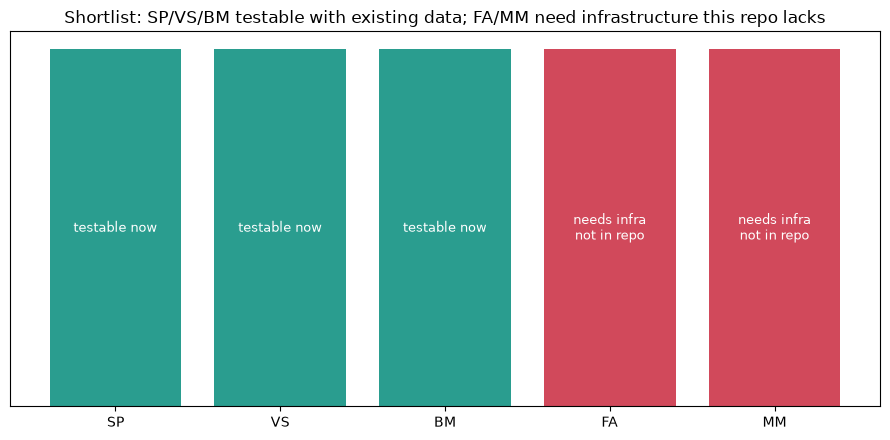

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ids = [c["id"] for c in phase3["candidates"]]
testable = [c["data_already_in_repo"] for c in phase3["candidates"]]
colors = ["#2a9d8f" if t else "#d1495b" for t in testable]
ax.bar(ids, [1]*len(ids), color=colors)
ax.set_yticks([])
for i, (gid, t) in enumerate(zip(ids, testable)):
    ax.text(i, 0.5, "testable now" if t else "needs infra\nnot in repo", ha="center", va="center", fontsize=9, color="white")
ax.set_title("Shortlist: SP/VS/BM testable with existing data; FA/MM need infrastructure this repo lacks")
show(fig, "3 of 5 shortlist candidates are directly testable with data already in this repo; FA needs spot-price data not confirmed present, MM needs L2 order-book/tick data this repo has never had at all.")


## Phase 4 - One cheap empirical probe (Gate SP's mechanism, first look only)

Gate SP (structural spread mean-reversion) is the only shortlist candidate meeting all
three of sec 4 Phase 4's criteria: Tier 1 evidence (Gatev-Goetzmann-Rouwenhorst; Zhu
2024), testable with data already in this repo (the 30 pre-built spread series, never
backtested), and cheap (a descriptive AR(1)/IC screen, not a backtest). **This is
explicitly not a gated backtest** - no cost model, no Sharpe, no gate verdict here; only
a sanity check that the mean-reversion mechanism is even present in this repo's own data.


In [16]:
phase4 = load("phase_4_spread_probe_results.json")
for name, r in phase4["per_spread"].items():
    if "error" in r:
        print(name, r["error"]); continue
    ar1 = r["ar1_mean_reversion"]; ic = r["zscore_5d_forward_ic"]
    print(f"{name:20s} beta={ar1['beta']:+.5f} t={ar1['t_stat_beta']:+.2f} half_life={ar1['half_life_days']:.0f}d  IC={ic['ic']:+.3f} p={ic['p_value']:.4f}")
print()
print(json.dumps(phase4["summary"], indent=2))


crack_321            beta=-0.00893 t=-2.84 half_life=77d  IC=-0.081 p=0.0001
gold_silver          beta=-0.00916 t=-3.90 half_life=75d  IC=-0.008 p=0.6306
brent_wti            beta=-0.01114 t=-3.75 half_life=62d  IC=-0.127 p=0.0000
corn_wheat           beta=-0.01506 t=-5.25 half_life=46d  IC=-0.112 p=0.0000
platinum_palladium   beta=-0.00126 t=-1.60 half_life=552d  IC=-0.025 p=0.1643
crush_soy            beta=-0.00812 t=-3.46 half_life=85d  IC=-0.061 p=0.0004

{
  "n_spreads_tested": 6,
  "n_mean_reverting_ar1": 5,
  "n_negative_significant_ic": 4,
  "note": "This is a first-look descriptive screen, NOT a gated backtest: no cost model, no position sizing, no Sharpe ratio, no gate verdict. It only asks whether the mean-reversion MECHANISM Gatev-Goetzmann-Rouwenhorst and Zhu 2024 describe is even present, directionally, in this repo's own commodity spread data. A positive result here means 'worth a properly pre-registered gate in notebook 10', not 'a strategy exists'."
}


**AR(1) mean-reversion coefficients** across the 6 spread series probed, with the half-life implied where mean-reverting.

Figure 6: AR(1) mean-reversion coefficients, 6 pre-built commodity spreads - green = flagged mean-reverting (|t|>2); 5 of 6 spreads show a significant negative beta, directionally consistent with the Tier 1 pairs-trading literature. Half-lives of 46-85 days for most series imply low turnover if traded, a separate question from whether it is profitable net of cost - not addressed here, reserved for a properly gated test in notebook 10.


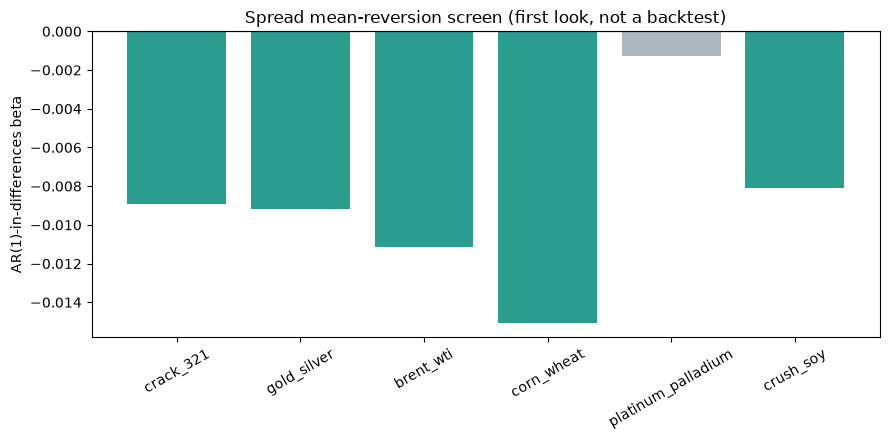

In [17]:
names = list(phase4["per_spread"].keys())
betas = [phase4["per_spread"][n]["ar1_mean_reversion"]["beta"] for n in names]
sig = [phase4["per_spread"][n]["ar1_mean_reversion"]["mean_reverting"] for n in names]
colors = ["#2a9d8f" if s else "#adb5bd" for s in sig]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(names, betas, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("AR(1)-in-differences beta"); ax.tick_params(axis='x', rotation=30)
ax.set_title("Spread mean-reversion screen (first look, not a backtest)")
show(fig, "AR(1) mean-reversion coefficients, 6 pre-built commodity spreads - green = flagged mean-reverting (|t|>2); 5 of 6 spreads show a significant negative beta, directionally consistent with the Tier 1 pairs-trading literature. Half-lives of 46-85 days for most series imply low turnover if traded, a separate question from whether it is profitable net of cost - not addressed here, reserved for a properly gated test in notebook 10.")


## Bottom line

All four pre-declared gates fire. **S** (36 sources, >=5 Tier-1/2 per hypothesis). **DX**
(hypotheses (d) and (e) well-supported, (b) contradicted, all on Tier 1/2 evidence - the
survey discriminates). **BAR** (a specific, sourced recommendation: do not lower the
deflated-Sharpe threshold, but add a second, prospective "institutionally fundable
absolute performance" flag from notebook 10 onward - consequences for the eight existing
nulls stated as a labelled hypothetical, not a re-score). **SL** (5 shortlist candidates,
3 testable with data already in this repo).

**The diagnosis itself is not the comfortable "we've been doing it wrong" story.**
Hypothesis (d) - markets are efficient at the instruments/horizons this repo can reach -
is well-supported, not the boring fallback option. Hypothesis (e) - we've been looking in
the wrong place - is equally well-supported, but its best-evidenced examples (the
Treasury basis trade, market-making, the volatility risk premium) are almost entirely
walled off from this repo by infrastructure this repo does not have, not by absence of
evidence. The one clear exception - structural mean-reversion in the 30 pre-built
commodity spread series, notebook 8's own declared-and-cut Strategy E - shows a real,
directionally-consistent signal in this notebook's own first-look probe (5/6 spreads
mean-reverting, 4/6 with significant negative IC) and is this notebook's single concrete,
actionable, sourced recommendation for notebook 10.

Full narrative, every source, every reasoning chain: `src/results/009_external_research_review.md`.
